In [74]:
from dataclasses import replace
import tabulate

from config.experiment import ExperimentConfig
from experiments import load_config
from config.task import generate_task_configs
from utils.plot import Metric, plot_metrics_vs_perturbation, get_metrics, shorten_model_name, strip_hf_org, PlotFilter

In [75]:
def get_config(cfg_name: str) -> ExperimentConfig:
    exp_cfg = load_config(cfg_name)

    return ExperimentConfig(
        train = replace(exp_cfg.train, save_folder = exp_cfg.train.save_folder.parent / "paper"),
        eval = replace(exp_cfg.eval, results_folder = exp_cfg.eval.results_folder.parent / "paper"),
    )

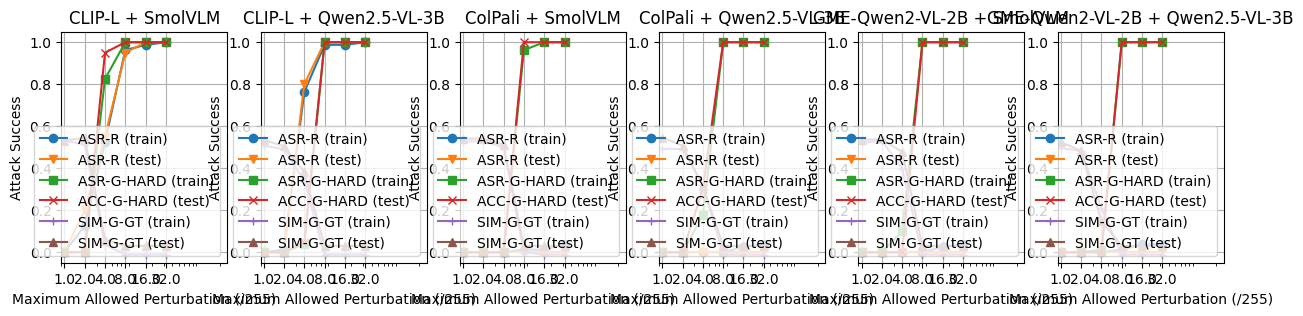

In [76]:
exp_config = get_config("paper_perturbation_plot")

plot_metrics_vs_perturbation(exp_config, metrics_to_show=[Metric.RETRIEVAL_ASR_TRAIN, Metric.RETRIEVAL_ASR_TEST, Metric.GENERATION_ASR_EXACT_TRAIN, Metric.GENERATION_ASR_EXACT_TEST, Metric.GENERATION_ACC_EMBED_GT_TRAIN, Metric.GENERATION_ACC_EMBED_GT_TEST], ret_topk_idx=0, gen_topk_idx=0)

In [77]:
# exp_config = get_config("perturbation_plot_targeted")
#
# plot_metrics_vs_perturbation(exp_config, metrics_to_show=[Metric.RETRIEVAL_ASR_TRAIN, Metric.RETRIEVAL_ASR_TEST,
#                                                           Metric.GENERATION_ASR_EXACT_TRAIN,
#                                                           Metric.GENERATION_ASR_EXACT_TEST,
#                                                           Metric.GENERATION_ACC_EMBED_GT_TRAIN,
#                                                           Metric.GENERATION_ACC_EMBED_GT_TEST], ret_topk_idx=0,
#                              gen_topk_idx=0)

In [78]:
def make_all_metric_table(config_name: str, metrics_to_show:list[Metric]|None=None, row_filter = None):
    exp_config = get_config(config_name)
    if metrics_to_show is None:
        metrics_to_show = [m for m in Metric]

    task_configs = generate_task_configs(exp_config, include_eval=True)

    table = []
    for task_config in task_configs:
        row = {
            "dataset": strip_hf_org(task_config.ds_name),
        }
        if not exp_config.eval.test_gpt_attack:
            row["embedder"] = shorten_model_name(task_config.model_name_embs[0]) if len(task_config.model_name_embs) == 1 else "+".join([shorten_model_name(m) for m in task_config.model_name_embs])
            if task_config.vlm:
                row["vlm"] = shorten_model_name(task_config.vlm.models[0]) if len(task_config.vlm.models) == 1 else "+".join([shorten_model_name(m) for m in task_config.vlm.models])
                if len(exp_config.train.vlm.gen_topk_list) > 1:
                    row["vlm topk"] = task_config.vlm.gen_topk
        if len(exp_config.train.emb_train_loss_type_list) > 1:
            row["emb train loss"] = task_config.emb_train_loss_type
        if len(exp_config.train.attack_mask_list) > 1:
            row["attack mask"] = task_config.attack_mask.name
        if task_config.eval_emb_name:
            row["eval emb"] = shorten_model_name(task_config.eval_emb_name)
        if task_config.eval_vlm_name:
            row["eval vlm"] = shorten_model_name(task_config.eval_vlm_name)

        if task_config.judge:
            row["judge"] = shorten_model_name(task_config.judge.model_name)
        if task_config.eval_jdg_name:
            row["eval judge"] = shorten_model_name(task_config.eval_jdg_name)
        metrics, _ = get_metrics(
            exp_config=exp_config,
            task_config=task_config,
            metrics_to_show=metrics_to_show,
        )
        row.update(metrics)
        table.append(row)
    if row_filter:
        table = [row for row in table if row_filter(row)]
    # return tabulate.tabulate(table, headers="keys", tablefmt="latex", showindex="never")
    return tabulate.tabulate(table, headers="keys", tablefmt="html", showindex="always")

In [79]:
make_all_metric_table("paper_non_targeted", metrics_to_show=PlotFilter.ALL_METRICS_UNTARGETED, row_filter=PlotFilter.CONDITION_SAME_MODELS)

,dataset,embedder,vlm,eval emb,eval vlm,Recall-B@1,Recall-A@1,ASR-R (test)@1,Recall-B@5,Recall-A@5,ASR-R (test)@5,ACC-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,CLIP-L,SmolVLM,0.21,0.02,1,0.44,0.43,1,1,1,0.0301554
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,CLIP-L,Qwen2.5-VL-3B,0.21,0.01,1,0.44,0.43,1,1,1,0.0301554
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,ColPali,SmolVLM,0.66,0.65,0,0.98,0.98,0.1,0.05,0.0525373,0.488216
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,ColPali,Qwen2.5-VL-3B,0.66,0.66,0,0.98,0.98,0.1,1,1,0.0301554
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,GME-Qwen2-VL-2B,SmolVLM,0.58,0.58,0,0.94,0.93,0.25,1,1,0.0301554
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.58,0,0.94,0.93,0.35,1,1,0.0301554


In [80]:
make_all_metric_table("paper_targeted_attacks_oneQ_oneA", row_filter=PlotFilter.CONDITION_SAME_MODELS, metrics_to_show=PlotFilter.ALL_METRICS_TARGETED)

,dataset,embedder,vlm,eval emb,eval vlm,ASR-R targeted@1,FPR-R targeted (test)@1,ASR-R targeted@5,FPR-R targeted (test)@5,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,CLIP-L,SmolVLM,1,0,1,0,0.979096,0.233345
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,CLIP-L,Qwen2.5-VL-3B,1,0,1,0.05,0.999978,0.234496
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,ColPali,SmolVLM,1,0,1,0,1,0.238917
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,ColPali,Qwen2.5-VL-3B,1,0,1,0,0.999977,0.225144
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,GME-Qwen2-VL-2B,SmolVLM,1,0,1,0,0.999978,0.199152
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,1,0,1,0,1,0.25367


In [81]:
make_all_metric_table("paper_targeted_attacks_multiQ_oneA", metrics_to_show=PlotFilter.ALL_METRICS_TARGETED)

,dataset,embedder,vlm,ASR-R targeted@1,FPR-R targeted (test)@1,ASR-R targeted@5,FPR-R targeted (test)@5,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,1,0,1,0,1,0.174183
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,0.8,0,0.8,0,1,0.492558
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,1,0,1,0,0.0982995,0.00474182
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,0.4,0,1,0,1,0.411617
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,0.6,0,0.6,0,1,0.0278113
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.6,0,0.8,0,0.792979,0.634126


In [82]:
make_all_metric_table("paper_targeted_attacks_multiQ_multiA", metrics_to_show=PlotFilter.ALL_METRICS_TARGETED)

,dataset,embedder,vlm,ASR-R targeted@1,FPR-R targeted (test)@1,ASR-R targeted@5,FPR-R targeted (test)@5,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,1,0,1,0,0.999991,0.269673
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,1,0,1,0,0.99998,0.269854
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,1,0,1,0,0.527364,0.260008
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,1,0,1,0,0.907934,0.274945
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,0.5,0,1,0,0.999989,0.262672
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.5,0,1,0,0.998746,0.257119


In [83]:
make_all_metric_table("paper_judge_defence", metrics_to_show=PlotFilter.METRICS_TEST_JUDGE)

,dataset,embedder,vlm,eval judge,Judge Image Content Relevancy (test)@-1,Judge Image Faithfulness (test)@-1,Judge Answer Relevancy (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,SmolVLM,0.55,0.3,0
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,Qwen2.5-VL-3B,0,0,0


In [84]:
make_all_metric_table("paper_judge_defence_adapt", metrics_to_show=PlotFilter.METRICS_TEST_JUDGE)

,dataset,embedder,vlm,judge,eval judge,Judge Image Content Relevancy (test)@-1,Judge Image Faithfulness (test)@-1,Judge Answer Relevancy (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,SmolVLM,SmolVLM,1,1,1
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,SmolVLM,Qwen2.5-VL-3B,0,0,0
2,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,Qwen2.5-VL-3B,SmolVLM,0.45,0.05,0.05
3,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,Qwen2.5-VL-3B,Qwen2.5-VL-3B,1,1,1


In [85]:
make_all_metric_table("paper_judge_defence_targeted", metrics_to_show=PlotFilter.METRICS_TEST_JUDGE)

,dataset,embedder,vlm,eval judge,Judge Image Content Relevancy (test)@-1,Judge Image Faithfulness (test)@-1,Judge Answer Relevancy (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,SmolVLM,0.65,0.75,0.2
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,Qwen2.5-VL-3B,0,0,0


In [86]:
make_all_metric_table("paper_judge_defence_targeted_adapt", metrics_to_show=PlotFilter.METRICS_TEST_JUDGE)

,dataset,embedder,vlm,judge,eval judge,Judge Image Content Relevancy (test)@-1,Judge Image Faithfulness (test)@-1,Judge Answer Relevancy (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,SmolVLM,SmolVLM,1,1,1
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,SmolVLM,Qwen2.5-VL-3B,0.05,0,0
2,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,Qwen2.5-VL-3B,SmolVLM,0.75,0.65,0
3,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,Qwen2.5-VL-3B,Qwen2.5-VL-3B,1,1,1


In [87]:
make_all_metric_table("paper_copali_ab", metrics_to_show=PlotFilter.METRICS_COLPALI)

,dataset,embedder,vlm,emb train loss,ASR-R (test)+maxsim@1,ASR-R (test)+maxsim@5,ASR-R (test)+avgsim@1,ASR-R (test)+avgsim@5,ASR-R (test)+softmaxsim@1,ASR-R (test)+softmaxsim@5,ASR-R (test)+cos_avgemb@1,ASR-R (test)+cos_avgemb@5
0,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,maxsim,0,0,0,0,0,0,0,0
1,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,avgsim,0,0,0.25,0.5,0.2,0.45,0.05,0.2
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,softmaxsim,0,0,0.25,0.4,0.15,0.35,0.1,0.25
3,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,cos_avgemb,0,0,0,0.05,0,0.05,0.05,0.1


In [88]:
make_all_metric_table("paper_copali_ab_cpoiT", metrics_to_show=PlotFilter.METRICS_COLPALI)

,dataset,embedder,vlm,emb train loss,ASR-R (test)+maxsim@1,ASR-R (test)+maxsim@5,ASR-R (test)+avgsim@1,ASR-R (test)+avgsim@5,ASR-R (test)+softmaxsim@1,ASR-R (test)+softmaxsim@5,ASR-R (test)+cos_avgemb@1,ASR-R (test)+cos_avgemb@5
0,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,maxsim,0,0.15,0,0,0,0,0,0
1,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,avgsim,0,0,0.25,0.45,0.15,0.35,0.1,0.2
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,softmaxsim,0,0.05,0.15,0.4,0.05,0.35,0.05,0.2
3,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,cos_avgemb,0,0.1,0.05,0.05,0,0.05,0.05,0.1


In [98]:
make_all_metric_table("paper_topk_context")

,dataset,embedder,vlm,vlm topk,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ACC-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1,ASR-G-HARD (train)@1,SIM-G-ADV (train)@1,SIM-G-GT (train)@1,ACC-G-HARD (test)@1,SIM-G-ADV (test)@1,SIM-G-GT (test)@1,ASR-G-HARD (train)@5,SIM-G-ADV (train)@5,SIM-G-GT (train)@5,ACC-G-HARD (test)@5,SIM-G-ADV (test)@5,SIM-G-GT (test)@5
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,1,0.21,0.02,0.95,0.95,0.44,0.43,1,1,1,1,-0.0109306,1,1,0.0301554,0.95,0.950121,0.0183201,0.95,0.947907,0.0650789,0,-0.044834,0.556429,0,-0.0287684,0.558359
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,5,0.21,0.02,0.8875,0.95,0.44,0.43,1,1,1,1,-0.0109306,1,1,0.0301554,0.8875,0.883195,0.0599936,0.95,0.946058,0.066424,0.95,0.950108,0.0123337,1,1,0.0301554


In [99]:
make_all_metric_table("paper_topk_context_targeted")

,dataset,embedder,vlm,vlm topk,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,ASR-R targeted@1,FPR-R targeted (train)@1,FPR-R targeted (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-R targeted@5,FPR-R targeted (train)@5,FPR-R targeted (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ACC-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1,ASR-G-HARD targeted (train)@-1,FPR-G-HARD targeted (train)@-1,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (train)@-1,FPR-G-HARD targeted (test)@-1,SIM-G-ADV-NEG targeted (test)@-1,ASR-G-HARD (train)@1,SIM-G-ADV (train)@1,SIM-G-GT (train)@1,ACC-G-HARD (test)@1,SIM-G-ADV (test)@1,SIM-G-GT (test)@1,ASR-G-HARD targeted (train)@1,FPR-G-HARD targeted (train)@1,SIM-G-ADV-POS targeted (train)@1,SIM-G-ADV-NEG targeted (train)@1,FPR-G-HARD targeted (test)@1,SIM-G-ADV-NEG targeted (test)@1,ASR-G-HARD (train)@5,SIM-G-ADV (train)@5,SIM-G-GT (train)@5,ACC-G-HARD (test)@5,SIM-G-ADV (test)@5,SIM-G-GT (test)@5,ASR-G-HARD targeted (train)@5,FPR-G-HARD targeted (train)@5,SIM-G-ADV-POS targeted (train)@5,SIM-G-ADV-NEG targeted (train)@5,FPR-G-HARD targeted (test)@5,SIM-G-ADV-NEG targeted (test)@5
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,1,0.21,0.21,0.0375,0,1,0.0253165,0,0.44,0.44,0.0625,0.05,1,0.0506329,0.05,0.0125,0.515278,0.502085,0,0.522859,0.522859,1,0.0126582,1,0.000341408,0,-0.00262511,0.0125,0.549166,0.535977,0,0.577131,0.577131,1,0,1,-0.0329354,0,-0.0140627,0,0.556047,0.566323,0,0.563142,0.563142,0,0,-0.0648307,-0.042247,0,-0.025339
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,5,0.21,0.21,0.0375,0,1,0.0253165,0,0.44,0.44,0.05,0,1,0.0379747,0,0.0125,0.51254,0.499351,0,0.56558,0.56558,1,0.0379747,1,0.0139359,0,0.0214569,0.0125,0.545008,0.531819,0,0.561652,0.561652,1,0.0126582,1,-0.0212291,0,-0.0181628,0.0125,0.545991,0.532802,0,0.54574,0.54574,1,0,1,-0.0442476,0,-0.0268381


In [90]:
make_all_metric_table("paper_defences")

,dataset,embedder,vlm,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ACC-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.21,0.02,0.925,0.95,0.44,0.43,1,1,0.9375,0.945258,0.00677132,0.95,0.961232,0.061236


In [91]:
make_all_metric_table("paper_targeted_defences")

,dataset,embedder,vlm,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,ASR-R targeted@1,FPR-R targeted (train)@1,FPR-R targeted (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-R targeted@5,FPR-R targeted (train)@5,FPR-R targeted (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ACC-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1,ASR-G-HARD targeted (train)@-1,FPR-G-HARD targeted (train)@-1,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (train)@-1,FPR-G-HARD targeted (test)@-1,SIM-G-ADV-NEG targeted (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.21,0.21,0.0375,0,1,0.0253165,0,0.44,0.44,0.0625,0,1,0.0506329,0,0.0125,0.476059,0.46287,0,0.550522,0.550522,1,0.0253165,1,-0.006509,0,-0.00303376


In [92]:
# make_all_metric_table("mask_attack")

In [93]:
make_all_metric_table("paper_GPT_non_targeted")

,dataset,eval emb,eval vlm,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ACC-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.21,0.21,0.0125,0,0.44,0.44,0.0125,0,0,-0.026943,0.524254,0,-0.0240033,0.549896
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,0.21,0.21,0.0125,0,0.44,0.44,0.0125,0,0,-0.000314868,0.497472,0,0.0144284,0.528623
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,0.66,0.65,0.0125,0,0.98,0.98,0.05,0,0,-0.0360425,0.534816,0,-0.00428852,0.515134
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,0.66,0.65,0.0125,0,0.98,0.98,0.05,0,0,-0.0154076,0.511872,0,0.00512495,0.544008
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,0.58,0.58,0,0,0.94,0.94,0.025,0,0,-0.0283802,0.536661,0,-0.0230045,0.533048
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.58,0,0,0.94,0.94,0.025,0,0,-0.00192698,0.499312,0,0.0189598,0.51165


In [94]:
make_all_metric_table("paper_GPT_targeted_attacks_oneQ_oneA")

,dataset,eval emb,eval vlm,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,ASR-R targeted@1,FPR-R targeted (train)@1,FPR-R targeted (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-R targeted@5,FPR-R targeted (train)@5,FPR-R targeted (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ACC-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1,ASR-G-HARD targeted (train)@-1,FPR-G-HARD targeted (train)@-1,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (train)@-1,FPR-G-HARD targeted (test)@-1,SIM-G-ADV-NEG targeted (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.21,0.21,0.025,0,1,0.0126582,0,0.44,0.44,0.0625,0,1,0.0506329,0,0,0.539556,0.53846,0,0.538404,0.538404,0,0,0.793339,0.296584,0,0.271321
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,0.21,0.21,0.025,0,1,0.0126582,0,0.44,0.44,0.0625,0,1,0.0506329,0,0,0.520324,0.514672,0,0.516903,0.516903,0,0,0.89461,0.270228,0,0.222097
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,0.66,0.65,0.025,0,1,0.0126582,0,0.98,0.98,0.0375,0,1,0.0253165,0,0.0125,0.515879,0.510015,0,0.530078,0.530078,1,0,0.999978,0.298927,0,0.341364
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,0.66,0.65,0.025,0,1,0.0126582,0,0.98,0.98,0.0375,0,1,0.0253165,0,0,0.520394,0.515204,0,0.553016,0.553016,0,0,0.9657,0.264141,0,0.23446
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,0.58,0.57,0.025,0,1,0.0126582,0,0.94,0.94,0.0375,0,1,0.0253165,0,0,0.533419,0.528292,0,0.547061,0.547061,0,0,0.966195,0.300508,0,0.303003
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.57,0.025,0,1,0.0126582,0,0.94,0.94,0.0375,0,1,0.0253165,0,0,0.523625,0.518291,0,0.543148,0.543148,0,0,0.928977,0.262979,0,0.245825


In [95]:
# make_all_metric_table("paper_GPT_targeted_attacks_multiQ_oneA")
# TODO: lacking 4/6 json files

In [96]:
make_all_metric_table("paper_GPT_targeted_attacks_multiQ_multiA")

,dataset,eval emb,eval vlm,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,ASR-R targeted@1,FPR-R targeted (train)@1,FPR-R targeted (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-R targeted@5,FPR-R targeted (train)@5,FPR-R targeted (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ACC-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1,ASR-G-HARD targeted (train)@-1,FPR-G-HARD targeted (train)@-1,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (train)@-1,FPR-G-HARD targeted (test)@-1,SIM-G-ADV-NEG targeted (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.21,0.21,0.0375,0,0.5,0.025641,0,0.44,0.44,0.0875,0,0.5,0.0769231,0,0,0.520107,0.520372,0,0.539938,0.539938,0,0,0.670754,0.31365,0,0.320573
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,0.21,0.21,0.0375,0,0.5,0.025641,0,0.44,0.44,0.0875,0,0.5,0.0769231,0,0,0.513502,0.505212,0,0.516776,0.516776,0,0,0.87528,0.30197,0,0.300047
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,0.66,0.66,0,0,0,0,0,0.98,0.98,0.0625,0,1,0.0384615,0,0,0.528273,0.526656,0,0.527111,0.527111,0,0,0.728126,0.312499,0,0.312731
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,0.66,0.66,0,0,0,0,0,0.98,0.98,0.0625,0,1,0.0384615,0,0,0.50932,0.501621,0,0.531593,0.531593,0,0,0.884722,0.304499,0,0.305826
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,0.58,0.57,0.0125,0,0.5,0,0,0.94,0.94,0.05,0,0.5,0.0384615,0,0,0.529643,0.524328,0,0.518941,0.518941,0,0,0.846674,0.315173,0,0.309567
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.57,0.0125,0,0.5,0,0,0.94,0.94,0.05,0,0.5,0.0384615,0,0,0.510294,0.504299,0,0.514876,0.514876,0,0,0.830613,0.309689,0,0.292673


In [97]:
make_all_metric_table("paper_multi_transferability")

,dataset,embedder,vlm,eval emb,eval vlm,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ACC-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L+GME-Qwen2-VL-2B,SmolVLM+Qwen2.5-VL-3B,CLIP-L,SmolVLM,0.21,0.06,0.8,0.9,0.44,0.43,0.975,1,0.9875,0.987641,-0.0061071,0.95,0.951629,0.0464323
1,syntheticDocQA_artificial_intelligence_test,CLIP-L+GME-Qwen2-VL-2B,SmolVLM+Qwen2.5-VL-3B,CLIP-L,Qwen2.5-VL-3B,0.21,0.06,0.8,0.9,0.44,0.43,0.975,1,1,1,-0.0109306,1,1,0.0301554
2,syntheticDocQA_artificial_intelligence_test,CLIP-L+GME-Qwen2-VL-2B,SmolVLM+Qwen2.5-VL-3B,GME-Qwen2-VL-2B,SmolVLM,0.58,0.58,0,0,0.94,0.93,0.125,0.25,1,1,-0.0109306,1,1,0.0301554
3,syntheticDocQA_artificial_intelligence_test,CLIP-L+GME-Qwen2-VL-2B,SmolVLM+Qwen2.5-VL-3B,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.58,0,0,0.94,0.93,0.125,0.25,1,1,-0.0109306,1,1,0.0301554
